In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 读取第i个sheet中的数据（此数据已经完成初步筛选）
file_path = r'E:\dataname.xlsx'
data = pd.read_excel(file_path, sheet_name=2)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# 仅选择位移数据
displacement_cols = data.columns[0:4]  
displacement_data = data[displacement_cols]

# 归一化
scalers = {}  
displacement_scaled = pd.DataFrame(index=displacement_data.index)  

for col in displacement_cols:
    scaler = MinMaxScaler(feature_range=(0, 1))
    displacement_scaled[col] = scaler.fit_transform(displacement_data[[col]])
    scalers[col] = scaler  

displacement_scaled = displacement_scaled.values

# 划分训练集和测试集
train_size = int(len(displacement_scaled) * 0.8)
train_data = displacement_scaled[:train_size]
test_data = displacement_scaled[train_size:]



Epoch 1/40
19/19 [==============================] - 4s 42ms/step - loss: 0.3933 - val_loss: 0.5591
Epoch 2/40
19/19 [==============================] - 0s 7ms/step - loss: 0.2315 - val_loss: 0.2728
Epoch 3/40
19/19 [==============================] - 0s 6ms/step - loss: 0.1271 - val_loss: 0.0940
Epoch 4/40
19/19 [==============================] - 0s 7ms/step - loss: 0.0930 - val_loss: 0.0629
Epoch 5/40
19/19 [==============================] - 0s 7ms/step - loss: 0.0877 - val_loss: 0.0652
Epoch 6/40
19/19 [==============================] - 0s 7ms/step - loss: 0.0803 - val_loss: 0.0625
Epoch 7/40
19/19 [==============================] - 0s 7ms/step - loss: 0.0777 - val_loss: 0.0527
Epoch 8/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0702 - val_loss: 0.0478
Epoch 9/40
19/19 [==============================] - 0s 7ms/step - loss: 0.0667 - val_loss: 0.0418
Epoch 10/40
19/19 [==============================] - 0s 7ms/step - loss: 0.0616 - val_loss: 0.0402
Epoch 11/40
19/19 

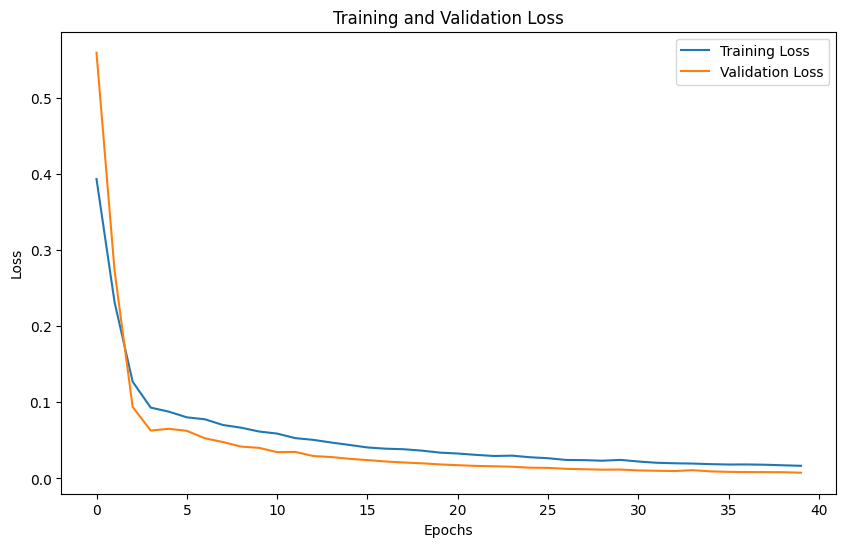

In [78]:
from tensorflow.keras.regularizers import l2
# 定义时间步长
time_steps = 2


def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps, 3])  
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, time_steps)
X_test, y_test = create_sequences(test_data, time_steps)

# 构建LSTM模型
model = Sequential([
    LSTM(25, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(15, return_sequences=False, kernel_regularizer=l2(0.002)),
    Dropout(0.3),
    Dense(15),
    Dense(1)
])


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=40, batch_size=64, validation_data=(X_test, y_test), verbose=1)

# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [79]:
# 进行预测
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 将预测结果逆归一化，仅对位移进行逆归一化
train_predict = scalers[displacement_cols[3]].inverse_transform(np.concatenate([train_predict] * len(displacement_cols), axis=1))[:, 0]
test_predict = scalers[displacement_cols[3]].inverse_transform(np.concatenate([test_predict] * len(displacement_cols), axis=1))[:, 0]

# 将真实值逆归一化
y_train_actual = scalers[displacement_cols[3]].inverse_transform(np.concatenate([y_train.reshape(-1, 1)] * len(displacement_cols), axis=1))[:, 0]
y_test_actual = scalers[displacement_cols[3]].inverse_transform(np.concatenate([y_test.reshape(-1, 1)] * len(displacement_cols), axis=1))[:, 0]

# 计算训练集和测试集的 R² 和 RMSE
from sklearn.metrics import r2_score, mean_squared_error

train_r2 = r2_score(y_train_actual, train_predict)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_r2 = r2_score(y_test_actual, test_predict)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"训练集 R²: {train_r2:.4f}")
print(f"训练集 RMSE: {train_rmse:.4f}")
print(f"测试集 R²: {test_r2:.4f}")
print(f"测试集 RMSE: {test_rmse:.4f}")



10/10 [==============================] - 0s 2ms/step
训练集 R²: 0.9907
训练集 RMSE: 16.9600
测试集 R²: 0.9139
测试集 RMSE: 4.9857


In [ ]:
# 导出预测结果到原 Excel 文件中的新 sheet
results_df = pd.DataFrame({
    'Date': data.index[-len(y_train_actual) - len(y_test_actual):],
    'Train_True': list(y_train_actual) + [None] * len(y_test_actual),
    'Train_Predict': list(train_predict) + [None] * len(y_test_actual),
    'Test_True': [None] * len(y_train_actual) + list(y_test_actual),
    'Test_Predict': [None] * len(y_train_actual) + list(test_predict)
})

# 指定文件路径和 sheet 名称
sheet_name = 'Trend_Predictions'

# 使用 ExcelWriter 将 DataFrame 写入 Excel 的新 sheet
with pd.ExcelWriter(file_path, mode='a', engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name=sheet_name)

print("趋势预测结果已成功导出到Excel文件的新sheet中。")